# 4. The composable pipeline tree

unitrack 2.0 builds trackers from a **typed tree of stages**.
There are three leaf signatures:

- `GateProducer: (cs, ds, ctx) → Gate`
- `CostProducer: (cs, ds, ctx) → CostExpression`
- `Associator: (cs, ds, ctx, cost?) → MatchOutcome`

and a small set of combinators that compose them:

- `Pipe(cost, assoc)` — bridge: cost → match.
- `Sequential[T]([s1, s2, …])` — chain of T-producers.
  For T=MatchOutcome: cascaded matching (residuals chain through).
  For T=Gate: gates fold under `Gate.combine`.
- `Parallel(children, merge)` — cost-level merge of K branches.
- `Gated(gate, then)` — apply a gate, then run the body.
- `Filter(predicate, on, then)` — drop rows of cs and/or ds.
- `Iterate(n, body)` — repeat a body n times.

This notebook builds and visualizes each combinator.


In [1]:
import torch
import matplotlib.pyplot as plt

from unitrack.assignment import Associate, Greedy, Jonker
from unitrack.costs import CDist, Cosine, MaskIoU, Reduce
from unitrack.data import Detections, FrameContext, Tracklets
from unitrack.gates import ClassGate, ScoreGate, SpatialGate2D
from unitrack.lifecycle import (
    MaxAgeFilter,
    StatusFilter,
    TrackletStatus,
)
from unitrack.pipeline import (
    Filter,
    Gated,
    Iterate,
    Parallel,
    Pipe,
    Sequential,
)
from unitrack.pipeline.merge import WeightedSum

torch.manual_seed(0)
ctx = FrameContext.make(0, delta=0.0)


## Common fixture

Three tracklets, four detections; all share a kernel field and
a class. We use the same data across each combinator so the
differences in their behavior are visible.


In [2]:
N, M = 3, 4
cs = Tracklets(
    id=torch.arange(N, dtype=torch.int64),
    status=torch.full((N,), int(TrackletStatus.Active), dtype=torch.int8),
    hits=torch.ones(N, dtype=torch.int32),
    time_since_update=torch.zeros(N, dtype=torch.int32),
    age=torch.tensor([1, 1, 6], dtype=torch.int32),  # last one is older
    frame_started=torch.zeros(N, dtype=torch.int32),
    frame_last_seen=torch.zeros(N, dtype=torch.int32),
    kernel=torch.tensor(
        [
            [1, 0, 0, 0, 0, 0, 0, 0],
            [0, 1, 0, 0, 0, 0, 0, 0],
            [0, 0, 1, 0, 0, 0, 0, 0],
        ],
        dtype=torch.float32,
    ),
    klass=torch.tensor([0, 1, 0]),
    position=torch.tensor([[0.0, 0.0], [50.0, 0.0], [100.0, 0.0]]),
    batch_size=[N],
)
ds = Detections(
    index=torch.arange(M, dtype=torch.int64),
    kernel=torch.tensor(
        [
            [0.95, 0.05, 0, 0, 0, 0, 0, 0],
            [0.05, 0.95, 0, 0, 0, 0, 0, 0],
            [0, 0.05, 0.95, 0, 0, 0, 0, 0],
            [0, 0, 0, 1, 0, 0, 0, 0],
        ],
        dtype=torch.float32,
    ),
    klass=torch.tensor([0, 1, 0, 2]),
    score=torch.tensor([0.9, 0.6, 0.4, 0.95]),
    position=torch.tensor([[2.0, 0.0], [49.0, 1.0], [98.0, 0.0], [200.0, 0.0]]),
    batch_size=[M],
)


In [3]:
def report(name: str, outcome):
    pairs = outcome.matched_pairs.tolist()
    res_cs = outcome.tracklets_residual_index.tolist()
    res_ds = outcome.detections_residual_index.tolist()
    print(f"{name:30s} matched={pairs}, residual cs={res_cs}, ds={res_ds}")


## The fixture, at a glance

Every combinator below runs on this same data, so it's worth
seeing it once. Squares are tracklets, circles are detections,
colored by class. The right panel is the appearance similarity
(cosine over `kernel`) between every tracklet and detection — the
diagonal three are near-matches, and `ds3` (class 2, novel
kernel) matches nothing. Watch how each combinator carves up
exactly this picture.


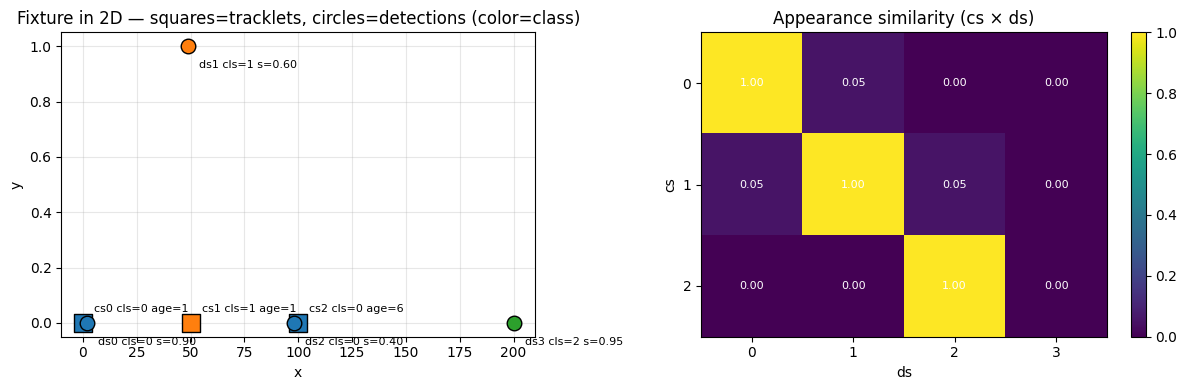

In [4]:
fig, (axp, axk) = plt.subplots(1, 2, figsize=(12, 4))
cmap = plt.get_cmap("tab10")

# (left) spatial layout, annotated with class / score / age.
for i in range(N):
    p = cs.position[i]
    axp.scatter(
        p[0],
        p[1],
        marker="s",
        s=170,
        color=cmap(int(cs.klass[i])),
        edgecolor="black",
        zorder=3,
    )
    axp.annotate(
        f"cs{i} cls={int(cs.klass[i])} age={int(cs.age[i])}",
        (p[0], p[1]),
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=8,
    )
for j in range(M):
    p = ds.position[j]
    axp.scatter(
        p[0],
        p[1],
        marker="o",
        s=110,
        color=cmap(int(ds.klass[j])),
        edgecolor="black",
        zorder=3,
    )
    axp.annotate(
        f"ds{j} cls={int(ds.klass[j])} s={ds.score[j]:.2f}",
        (p[0], p[1]),
        textcoords="offset points",
        xytext=(8, -16),
        fontsize=8,
    )
axp.set_title("Fixture in 2D — squares=tracklets, circles=detections (color=class)")
axp.set_xlabel("x")
axp.set_ylabel("y")
axp.grid(alpha=0.3)

# (right) appearance similarity, cs x ds.
kn = torch.nn.functional.normalize
sim = kn(cs.kernel, dim=-1) @ kn(ds.kernel, dim=-1).T
im = axk.imshow(sim.numpy(), cmap="viridis", vmin=0, vmax=1)
axk.set_title("Appearance similarity (cs × ds)")
axk.set_xlabel("ds")
axk.set_ylabel("cs")
axk.set_xticks(range(M))
axk.set_yticks(range(N))
for i in range(N):
    for j in range(M):
        axk.text(
            j,
            i,
            f"{sim[i, j]:.2f}",
            ha="center",
            va="center",
            color="white",
            fontsize=8,
        )
fig.colorbar(im, ax=axk, fraction=0.046)
plt.tight_layout()
plt.show()


## Pipe — the cost→match bridge

The simplest end-to-end stage: compute a cost, run an
assignment.


In [5]:
pipe = Pipe(cost=Cosine("kernel"), assoc=Associate(Jonker(threshold=0.5)))
report("Pipe(Cosine + Jonker)", pipe(cs, ds, ctx))


Pipe(Cosine + Jonker)          matched=[[0, 0], [1, 1], [2, 2]], residual cs=[], ds=[3]


## Gated — apply a gate before the body

Gated is the wrap-this-with-a-gate combinator. With a per-pair
ClassGate, only same-class pairs are allowed before matching.


In [6]:
gated = Gated(gate=ClassGate("klass"), then=pipe)
report("Gated(ClassGate, Pipe)", gated(cs, ds, ctx))

# Same Pipe gated by ScoreGate (per-detection)
gated_score = Gated(gate=ScoreGate("score", threshold=0.7), then=pipe)
report("Gated(ScoreGate>0.7, Pipe)", gated_score(cs, ds, ctx))


Gated(ClassGate, Pipe)         matched=[[0, 0], [1, 1], [2, 2]], residual cs=[], ds=[3]
Gated(ScoreGate>0.7, Pipe)     matched=[[0, 0]], residual cs=[1, 2], ds=[3, 1, 2]


## Sequential — cascaded matching

`Sequential[MatchOutcome]([s1, s2, …])` chains stages: each
child's residuals (unmatched cs, unmatched ds) feed the next.
This is cascaded fusion.


In [7]:
# Stage 1: strict cosine match (only near-perfect kernel similarity).
# Stage 2: relaxed CDist on position for the leftovers.
seq = Sequential(
    [
        Pipe(cost=Cosine("kernel"), assoc=Associate(Jonker(threshold=0.06))),
        Pipe(cost=CDist("position"), assoc=Associate(Jonker(threshold=10.0))),
    ]
)
report("Sequential(strict, then relaxed)", seq(cs, ds, ctx))


Sequential(strict, then relaxed) matched=[[0, 0], [1, 1], [2, 2]], residual cs=[], ds=[3]


Reading the result: stage 1 found two strong cosine matches;
stage 2 picked up the remaining tracklet via position
proximity.

## Sequential[Gate] — folding gates

Sequential of gate-producers folds children with `Gate.combine`.
That gives you a single gate that's the conjunction of all the
child gates.


In [8]:
gate_chain = Sequential(
    [
        ClassGate("klass"),
        ScoreGate("score", threshold=0.5),
    ]
)
composed = gate_chain(cs, ds, ctx)
print(f"composed gate kind: {composed.kind}")
print(f"composed mask:")
print(composed.mask.int())


composed gate kind: per_pair
composed mask:
tensor([[1, 0, 0, 0],
        [0, 1, 0, 0],
        [1, 0, 0, 0]], dtype=torch.int32)


## Parallel — cost-level merge

`Parallel(children, merge)` runs each child *on the same input*
and combines their CostExpressions via a `Merge` strategy.
This is parallel fusion. Branches must be cost-
producers (not associators).


In [9]:
parallel = Parallel(
    children=[Cosine("kernel"), CDist("position")],
    merge=WeightedSum([1.0, 0.05]),
)
# Wrap in a Pipe so we can run it end-to-end.
pipe_parallel = Pipe(cost=parallel, assoc=Associate(Jonker(threshold=0.6)))
report("Parallel(Cosine, 0.05·CDist)", pipe_parallel(cs, ds, ctx))


Parallel(Cosine, 0.05·CDist)   matched=[[0, 0], [1, 1], [2, 2]], residual cs=[], ds=[3]


## Filter — drop rows by predicate

`Filter(predicate, on, then)` drops cs (or ds, or both) before
the body runs. Common predicates live in
`unitrack.lifecycle`:

- `MaxAgeFilter(max_age=N)` — keep tracklets matched within
  the last N frames.
- `StatusFilter(*statuses)` — keep tracklets in the listed
  status set.


In [10]:
# Drop tracklets aged > 4 (only cs[2] in our fixture has age=6).
filtered = Filter(MaxAgeFilter(max_age=4), on="cs", then=pipe)
report("Filter(MaxAgeFilter(<=4), Pipe)", filtered(cs, ds, ctx))

# Inspect what was filtered:
print("\nages:", cs.age.tolist())
print("After Filter, residual cs includes the filtered-out tracklet.")


Filter(MaxAgeFilter(<=4), Pipe) matched=[[0, 0], [1, 1], [2, 2]], residual cs=[], ds=[3]

ages: [1, 1, 6]
After Filter, residual cs includes the filtered-out tracklet.


Note that the filtered-out tracklet (index 2, age=6) appears
in `tracklets_residual_index` — Filter remaps indices back to
the unfiltered space and adds the dropped rows to the residual,
so the parent stage doesn't see "missing" tracklets.

## Iterate — repeat a body

`Iterate(n, body)` is `Sequential[MatchOutcome]([body] * n)` as
a single configuration knob — handy for HPO over the number of
cascaded stages.


In [11]:
loop = Iterate(n=2, body=pipe)
report("Iterate(n=2, Pipe(Cosine))", loop(cs, ds, ctx))


Iterate(n=2, Pipe(Cosine))     matched=[[0, 0], [1, 1], [2, 2]], residual cs=[], ds=[3]


## Side-by-side: cascaded vs parallel fusion

On the same data, cascaded and parallel often produce different
match sets. K=2 cascaded tends to outperform parallel.
Here we verify the two paths produce the right shapes.


In [12]:
cascaded = Sequential(
    [
        Pipe(cost=Cosine("kernel"), assoc=Associate(Jonker(threshold=0.4))),
        Pipe(cost=CDist("position"), assoc=Associate(Jonker(threshold=10.0))),
    ]
)
parallel = Pipe(
    cost=Parallel(
        children=[Cosine("kernel"), CDist("position")],
        merge=WeightedSum([1.0, 0.05]),
    ),
    assoc=Associate(Jonker(threshold=0.6)),
)
report("CASCADED  (Cosine → CDist)", cascaded(cs, ds, ctx))
report("PARALLEL  (Cosine + 0.05·CDist)", parallel(cs, ds, ctx))


CASCADED  (Cosine → CDist)     matched=[[0, 0], [1, 1], [2, 2]], residual cs=[], ds=[3]
PARALLEL  (Cosine + 0.05·CDist) matched=[[0, 0], [1, 1], [2, 2]], residual cs=[], ds=[3]


## What's next

Notebook **5** introduces **state evolution** and the
**lifecycle policy** — the parts of unitrack that keep
tracklets alive across frames, even when they aren't matched
on every frame.
